In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("Salary_Data.csv")

In [3]:
df.shape

(30, 2)

Text(0, 0.5, 'Salary')

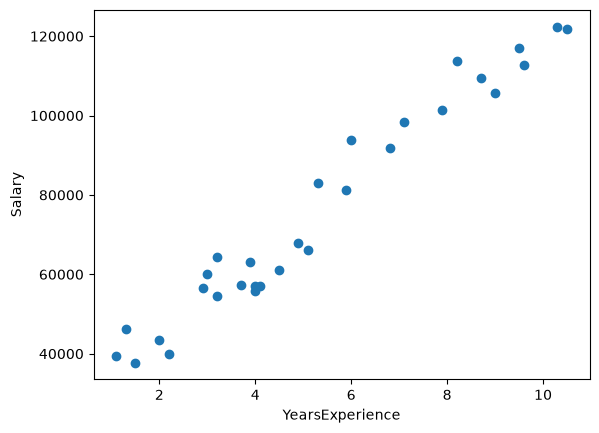

In [4]:
plt.scatter(df['YearsExperience'],df['Salary'])
plt.xlabel('YearsExperience')
plt.ylabel('Salary')

In [5]:
x = df[['YearsExperience']]
y = df['Salary']

In [6]:
from sklearn.model_selection import train_test_split

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [9]:
x_train.shape

(22, 1)

In [10]:
x_test.shape

(8, 1)

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler = StandardScaler()

In [13]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [14]:
from sklearn.linear_model import LinearRegression

In [16]:
model = LinearRegression(n_jobs=-1)

In [17]:
model.fit(x_train,y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[25063.15]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.042e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.69]


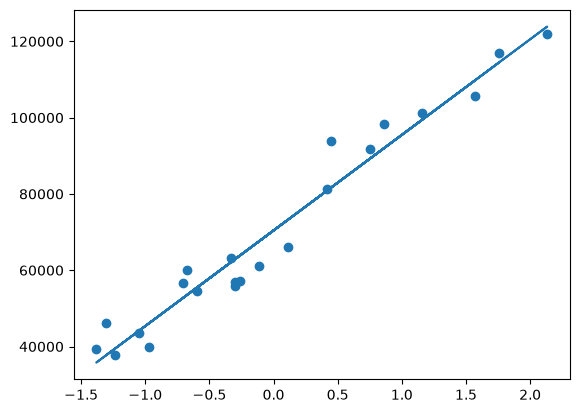

In [18]:
plt.scatter(x_train,y_train)
plt.plot(x_train,model.predict(x_train))


In [19]:
y_pred = model.predict(x_test)

In [20]:
print("Actual:", y_test.values[:5])
print("Predicted:", y_pred[:5])

Actual: [112635.  67938. 113812.  83088.  64445.]
Predicted: [115439.88180109  71396.10622651 102320.45928951  75144.51265839
  55465.37889103]


In [26]:
## Prediction For new data
model.predict(scaler.transform([[13.0]]))

c:\Users\karan\OneDrive\Desktop\LinearRegression\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([147301.33647206])

In [27]:
new_data = pd.DataFrame({
  'YearsExperience': [13]
})
prediction = model.predict(scaler.transform(new_data))
print("Predicted Salary :" ,prediction[0])

Predicted Salary : 147301.33647205617
